In [1]:
# ==============================
# 1. Imports
# ==============================

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, recall_score, precision_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# For reproducibility
RANDOM_STATE = 42

In [2]:
# ==============================
# 2. Load Final Training Data
# ==============================

train_df = pd.read_csv("../data/processed/train_final.csv")

print("Shape:", train_df.shape)
train_df.head()

Shape: (1486, 7)


,log_pl_orbsmax,log_st_lum,log_pl_rade,log_teq,log_st_teff,log_stellar_flux,habitable
0,-0.255128,0.903445,-0.360182,0.531316,0.515772,0.595122,0
1,-0.257927,0.695227,-0.767733,0.476395,0.481507,0.515846,0
2,-0.122958,-0.321166,-0.391518,-0.366665,0.161508,-0.677869,0
3,-0.341789,0.298404,1.398775,0.848777,0.871896,1.054154,0
4,3.458908,0.392995,1.099040,-2.636207,0.696510,-1.885888,0


In [3]:
# ==============================
# 3. Separate Features & Target
# ==============================

TARGET_COLUMN = "habitable"   # change if your column name differs

X = train_df.drop(columns=[TARGET_COLUMN])
y = train_df[TARGET_COLUMN]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

X shape: (1486, 6)
y shape: (1486,)

Class distribution:
habitable
0    1478
1       8
Name: count, dtype: int64


In [4]:
# ==============================
# 4. Logistic Regression Pipeline
# ==============================

logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

# Define evaluation metrics
scoring = {
    "recall": make_scorer(recall_score),
    "precision": make_scorer(precision_score)
}

# Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Cross-validation
logreg_results = cross_validate(
    logreg_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Recall per fold:", logreg_results["test_recall"])
print("Mean Recall:", np.mean(logreg_results["test_recall"]))
print("-" * 40)
print("Precision per fold:", logreg_results["test_precision"])
print("Mean Precision:", np.mean(logreg_results["test_precision"]))

Recall per fold: [1. 1. 1. 1. 1.]
Mean Recall: 1.0
----------------------------------------
Precision per fold: [0.33333333 0.11111111 0.2        0.25       0.33333333]
Mean Precision: 0.24555555555555553


In [5]:
# ==============================
# 5. Decision Tree Pipeline
# ==============================

tree_pipeline = Pipeline([
    ("model", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

tree_results = cross_validate(
    tree_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Recall per fold:", tree_results["test_recall"])
print("Mean Recall:", np.mean(tree_results["test_recall"]))
print("-" * 40)
print("Precision per fold:", tree_results["test_precision"])
print("Mean Precision:", np.mean(tree_results["test_precision"]))

Recall per fold: [0.5 1.  1.  1.  1. ]
Mean Recall: 0.9
----------------------------------------
Precision per fold: [1. 1. 1. 1. 1.]
Mean Precision: 1.0


In [6]:
# ==============================
# 6. Random Forest Pipeline
# ==============================

rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

rf_results = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Recall per fold:", rf_results["test_recall"])
print("Mean Recall:", np.mean(rf_results["test_recall"]))
print("-" * 40)
print("Precision per fold:", rf_results["test_precision"])
print("Mean Precision:", np.mean(rf_results["test_precision"]))

c:\Users\Samyukthaa\exoplanet-habitability-project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Samyukthaa\exoplanet-habitability-project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Recall per fold: [0.5 1.  0.  0.  1. ]
Mean Recall: 0.5
----------------------------------------
Precision per fold: [1. 1. 0. 0. 1.]
Mean Precision: 0.6


In [7]:
# ==============================
# 7. Gradient Boosting Pipeline
# ==============================

gb_pipeline = Pipeline([
    ("model", GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ))
])

gb_results = cross_validate(
    gb_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Recall per fold:", gb_results["test_recall"])
print("Mean Recall:", np.mean(gb_results["test_recall"]))
print("-" * 40)
print("Precision per fold:", gb_results["test_precision"])
print("Mean Precision:", np.mean(gb_results["test_precision"]))

Recall per fold: [0.5 1.  1.  0.  0.5]
Mean Recall: 0.6
----------------------------------------
Precision per fold: [0.5        0.33333333 1.         0.         1.        ]
Mean Precision: 0.5666666666666667


In [8]:
# ==============================
# 8. Model Comparison Summary
# ==============================

results_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Mean Recall": [
        np.mean(logreg_results["test_recall"]),
        np.mean(tree_results["test_recall"]),
        np.mean(rf_results["test_recall"]),
        np.mean(gb_results["test_recall"])
    ],
    "Mean Precision": [
        np.mean(logreg_results["test_precision"]),
        np.mean(tree_results["test_precision"]),
        np.mean(rf_results["test_precision"]),
        np.mean(gb_results["test_precision"])
    ]
})

results_summary.sort_values(by="Mean Recall", ascending=False)

,Model,Mean Recall,Mean Precision
0,Logistic Regression,1.0,0.245556
1,Decision Tree,0.9,1.000000
3,Gradient Boosting,0.6,0.566667
2,Random Forest,0.5,0.600000


In [9]:
# ==============================
# 9. SMOTE + Logistic Regression Pipeline
# ==============================

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight=None,
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

smote_results = cross_validate(
    smote_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Recall per fold:", smote_results["test_recall"])
print("Mean Recall:", np.mean(smote_results["test_recall"]))
print("-" * 40)
print("Precision per fold:", smote_results["test_precision"])
print("Mean Precision:", np.mean(smote_results["test_precision"]))

Recall per fold: [1. 1. 1. 1. 1.]
Mean Recall: 1.0
----------------------------------------
Precision per fold: [0.33333333 0.14285714 0.33333333 0.33333333 0.5       ]
Mean Precision: 0.32857142857142857


In [10]:
# ==============================
# 10. Updated Model Comparison
# ==============================

results_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression + SMOTE",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Mean Recall": [
        np.mean(logreg_results["test_recall"]),
        np.mean(smote_results["test_recall"]),
        np.mean(tree_results["test_recall"]),
        np.mean(rf_results["test_recall"]),
        np.mean(gb_results["test_recall"])
    ],
    "Mean Precision": [
        np.mean(logreg_results["test_precision"]),
        np.mean(smote_results["test_precision"]),
        np.mean(tree_results["test_precision"]),
        np.mean(rf_results["test_precision"]),
        np.mean(gb_results["test_precision"])
    ]
})

results_summary.sort_values(by="Mean Recall", ascending=False)

,Model,Mean Recall,Mean Precision
0,Logistic Regression,1.0,0.245556
1,Logistic Regression + SMOTE,1.0,0.328571
2,Decision Tree,0.9,1.000000
4,Gradient Boosting,0.6,0.566667
3,Random Forest,0.5,0.600000


In [11]:
# ==============================
# 11. Train Final Logistic + SMOTE Model
# ==============================

final_model = smote_pipeline

final_model.fit(X, y)

print("Final model trained successfully.")

Final model trained successfully.


In [12]:
# ==============================
# 12. Extract Feature Importance
# ==============================

# Get coefficients from logistic regression
coefficients = final_model.named_steps["model"].coef_[0]

# Create dataframe for readability
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

# Sort by influence
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
1,log_st_lum,-0.773549
0,log_pl_orbsmax,-1.732821
4,log_st_teff,-2.553753
3,log_teq,-2.668972
5,log_stellar_flux,-4.230047
2,log_pl_rade,-5.419328


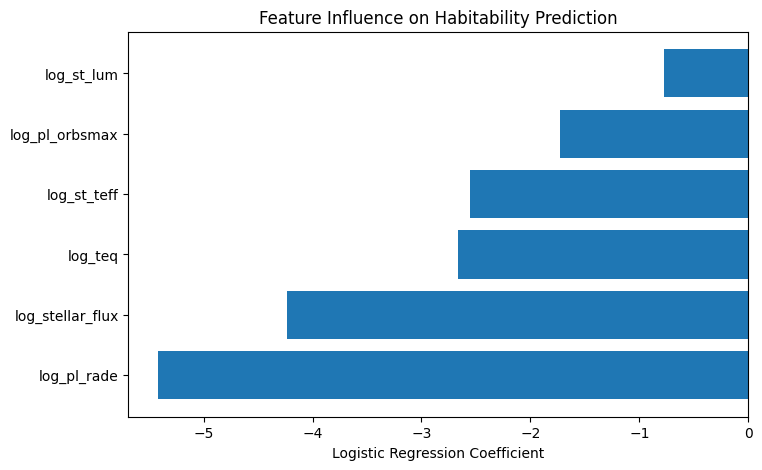

In [13]:
# ==============================
# 13. Visualize Feature Importance
# ==============================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.title("Feature Influence on Habitability Prediction")

plt.gca().invert_yaxis()

plt.show()

In [14]:
# ==============================
# 14. Load Test Dataset
# ==============================

test_df = pd.read_csv("../data/processed/test_final.csv")

print("Shape:", test_df.shape)
test_df.head()

Shape: (372, 7)


,log_pl_orbsmax,log_st_lum,log_pl_rade,log_teq,log_st_teff,log_stellar_flux,habitable
0,-0.295167,-0.841653,-1.318503,-0.248592,-0.896215,-0.516193,0
1,-0.206028,-0.822152,-0.623542,-0.588329,-1.049192,-0.969116,0
2,5.161499,-1.019647,1.196129,-5.353629,-3.294966,-1.889797,0
3,-0.332822,0.544322,1.039218,0.859548,1.200465,1.069744,0
4,-0.204441,-0.022023,-1.357912,0.008258,0.475332,-0.155590,0


In [15]:
# ==============================
# 15. Prepare Test Data
# ==============================

X_test = test_df.drop(columns=[TARGET_COLUMN])
y_test = test_df[TARGET_COLUMN]

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTest class distribution:")
print(y_test.value_counts())

X_test shape: (372, 6)
y_test shape: (372,)

Test class distribution:
habitable
0    370
1      2
Name: count, dtype: int64


In [16]:
# ==============================
# 16. Final Model Evaluation
# ==============================

from sklearn.metrics import confusion_matrix, recall_score, precision_score

# Predictions
y_pred = final_model.predict(X_test)

# Metrics
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print("Recall:", recall)
print("Precision:", precision)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Recall: 1.0
Precision: 0.16666666666666666

Confusion Matrix:
[[360  10]
 [  0   2]]


In [21]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])